In [1]:
''' 

Measure mean, stdev, kurtosis and skew from pedestal data file and compare them to the v3a 
requirement standards.

'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import scipy

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev, median
from pathlib import Path
from scipy.signal import find_peaks, peak_widths
from scipy.stats import truncnorm
from scipy.optimize import brentq

##########################################################
# Initialize parameters  
##########################################################

# early data from 5-tile cold pedestal run (before power settings were optimized, in large cryo)
#filename = "/data/v3/10x16/subset_tests_5tiles_20251028/cold/packet-cold_pedestal_4tiles-2025_10_28_17_25_23_PDT.h5"

# only tile 10 powered up, warm test
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/warm/packet-warm_ped_480s_drops_t10_185vref.hdf5"
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/warm/packet-warm_ped_480s_drops_t10_220vref.hdf5"

# only tile 10 powered up, cold tests (before power settings were optimized, in large cryo)
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_1.hdf5"
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_2.hdf5"
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_3.hdf5"
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_4.hdf5"
#filename = "/data/v3/10x16/tile_4k04087_tests_20260206/data/cold/packet-cold_ped_150kcycles_480s_t10_no_drop.hdf5"

# warm tests set 1 of 10tiles when there was significant noise due to a large power draw from the chi
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214/data/warm/packet-warm_ped_720s_10tiles_no_hotchan_drops_220vref_1.hdf5"
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214/data/warm/packet-warm_ped_720s_no_hotchan_drops_220vref_1.hdf5"
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214/data/warm/packet-warm_ped_720s_no_hotchan_drops_220vref_2.hdf5"
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214s/data/warm/packet-warm_ped_720s_no_hotchan_drops_220vref_3.hdf5"
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214/data/warm/packet-warm_ped_720s_10tiles_no_hotchan_185vref_1.hdf5"
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214/data/warm/packet-warm_ped_720s_10tiles_no_hotchan_185vref_2.hdf5"
#filename = "/data/v3/10x16/set1_10_tile_tests_20260214/data/warm/packet-warm_ped_720s_10tiles_no_hotchan_185vref_3.hdf5"

# warm tests of set 2 of 9 tiles (before complete) grounding where trigger cycles and vref were varied
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/ungrounded_datafiles/packet-warm_ped_600s_set2_10tiles_drop_pkts_1.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/ungrounded_datafiles/packet-warm_ped_480s_set2_9tiles_185vref_1.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/ungrounded_datafiles/packet-warm_ped_120s_set2_9tiles_220vref.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/ungrounded_datafiles/packet-warm_ped_480s_set2_9tiles_185vref_3.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/ungrounded_datafiles/packet-warm_ped_480s_set2_9tiles_185vref_4.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/ungrounded_datafiles/packet-warm_ped_480s_set2_9tiles_185vref_1_w_sync.hdf5"

# warm tests: set2 of 9 tiles after sufficient cryo grounding
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/packet-warm_ped_480s_set2_9tiles_185vref_1.hdf5"

# warm tests of set 2 of 10 tiles (tile 4 was replaced with tile 10 from set 1)
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/warm/packet-warm_ped_set2_10tiles_240s_185vref_no_hotchan_3.hdf5"
 
# cold test of set 2, 10 tiles
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_ped_set2_10tiles_480s_220vref_1.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_ped_set2_10tiles_480s_220vref_2.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_ped_set2_10tiles_480s_220vref_3.hdf5"
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_ped_set2_10tiles_480s_220vref_4.hdf5"

# cold test of set 3, 9 tiles
#filename = "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_1.hdf5"
#filename = "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_2.hdf5"
#filename = "/data/v3/10x16/set3_10_tile_tests_20260505/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_3.hdf5"
filename = "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_4.hdf5"

# cold test of set 4, 10 tiles
#filename = "/data/v3/10x16/set4_10_tile_tests_20260512/cold/packet-cold_ped_set4_10tiles_240s_no_hotchan_1.hdf5"
#filename = "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_ped_set4_10tiles_240s_no_hotchan_2.hdf5"
#filename = "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_ped_set4_10tiles_240s_no_hotchan_3.hdf5"
#filename = "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_ped_set4_10tiles_240s_no_hotchan_links_disabled.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
#tiles = [1,2,3,4,5,6,7,8,9,10]
tiles = [2]

# if certain channels are known to be problematic, and you don't want them skewing the pedestal distributions,
# specify them here. These channels will not be analysed or recorded in the results dictionary
#omitted_channels = [0,56,57,58]
omitted_channels = []

# serial numbers for sets 1-4 of 10 tiles
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]
set_n = 1
if "set2" in filename:
    set_n = 2
    chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]
elif "set3" in filename:
    set_n = 3
    chip_serial_number_list = ['', '4k00952', '4k03591', '4k03936', '4k00607', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]
elif "set4" in filename:
    set_n = 4    
    chip_serial_number_list = ['', '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]    

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

# temp records if test was conducted cold (typically in LN) or warm (room temp)
if "warm" in filename:
    temp = "warm"
    vref_dac = 185
elif "cold" in filename:
    temp = "cold"
    vref_dac = 220
else:
    print(f"The filename did not indicate if this was a cold or warm run")
    temp = "warm/cold not indicated"

# to determine unstable means, unstable_pkt_count establishes the # of packets in mean taken over
# a rolling window and compares that mean to the total channel mean. If the difference is greater
# than unstable_diff the channel will be flagged and graphed for unstable means
unstable_pkt_count = 20
unstable_diff = 2
n_unstable_graphs = 5
count_unstable = 0

# needed for conversion from dataword to electrons
n_adc_bits = 10
vdda = 2077
gain = 3.4      # Jaafar's gain measurement

# the number of noisy channels to graph for each tile
n_noisy_graphs = 5

# number of stdev to tructated pedestal distribution before calculating the final stdev
n_stdev = 2.5

# the following values are being initialized to zero
nenabled_chips = 0
ig = 1 
files = []
first_tile = True
kurtosis_list, kurtosis_percent_list = [], []
verbose = False
kurtosis_chips = []
n_duplicates = 0
all_mean, all_std = [], []
all_bad_mean = 0
all_nchan = 0
ntiles = 0
n_extreme = 0

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
# determine pedestal stability through time by measuring the difference between the mean pedestal for all pkts (roughly 3.5k
# per channel for a 480s run) and the mean pedestal for every 100 pkts. 
def word_stability(mean_all_pkts, pkts, tile, chip, chan, kurtosis):

    global mean_diff, n_segments, unstable_pkt_count, unstable_diff, n_unstable_graphs, count_unstable, verbose
    global count_stable_low_kurtosis, count_unstable_high_std

    # initialize
    unstable = False
    segment = 0
    less_stable_means = []
    
    # divide the pkts into sub-segments to see if they have stable means
    n_segments = len(pkts) - unstable_pkt_count - 1
    
    # calculate the mean for each segment and determine if its stable
    for s in range(n_segments):

        mean_segment = np.mean( pkts[ s : s + unstable_pkt_count] )
        
        # calculate the difference in the mean for this segment and the mean for all packets
        diff = mean_all_pkts - mean_segment
        
        mean_diff.append(diff)

        # if the segment mean is off by more than 2 kilo-electrons, flag this difference for printing and graphing
        if abs(diff) > unstable_diff:
            less_stable_means.append(int(mean_segment))
            unstable = True    

        segment +=1

    pkt_stdev = np.std(pkts)
    
    if unstable and verbose:
            print(f"\nTile-Chip-Channel {tile}-{chip}-{chan}: {mean_all_pkts:.0f} had an un-stable mean using a {unstable_pkt_count}-pkt rolling mean window")

    if pkt_stdev > 2:
        
        if not unstable and kurtosis < 0:
            
            count_stable_low_kurtosis +=1           
        
        elif unstable:
            
            count_unstable_high_std +=1

            if count_unstable < n_unstable_graphs:

                count_unstable +=1
                
                fig, ax = plt.subplots(1,1,figsize=(6, 3))
                plt.title(f"Unstable Pedestal Tile-Chip-Channel {tile}-{chip}-{chan}\nStdev {pkt_stdev:.1f}, Mean = {mean_all_pkts:.0f}, Kurtosis {kurtosis:.1f}\nBenchtop Test of v3a Tile #{tile} ({chip_serial_number})")    
                ax.plot(pkts, color = 'b')
                ax.set_xlabel(f'Packet Number')
                #ax.set_yscale('log') 
                ax.set_ylabel(f'Pedestal (kilo-electrons)')  
        
                fig, ax = plt.subplots(1,1,figsize=(6, 3))
                plt.title(f"Unstable Pedestal Tile-Chip-Channel {tile}-{chip}-{chan}\nStdev {pkt_stdev:.1f}, Mean = {mean_all_pkts:.0f}, Kurtosis {kurtosis:.1f}\nBenchtop Test of v3a Tile #{tile} ({chip_serial_number})")    
                ax.hist(pkts, color = 'b', bins = 40)
                ax.set_xlabel(f'Pedestal')
                ax.set_yscale('log') 
                ax.set_ylabel(f'Pedestal (kilo-electrons)')  
        
    return
    

In [4]:
def skewness(data, chip, chan):
    """
    Calculate sample skewness (Fisher-Pearson).
    """
    
    data = np.array(data, dtype=float)
    n = len(data)
    if n < 3:
        raise ValueError(f"At least 3 data points required for skewness. Channel {chip}-{chan} only had {n}.")
    
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)  
    m3 = np.mean((data - mean) ** 3)
    
    # Fisher-Pearson coefficient of skewness
    if n > 3 and std_dev > 0:
        skew = (np.sqrt(n * (n - 1)) / (n - 2)) * (m3 / (std_dev ** 3))
    else:
        skew = 0  
        print(f'Problem calculating skew for chip-chan {chip}-{chan}, {len(non_zero_chan_adc)} pkts, mean ped {mean_adc:.0f}, stdev {std_adc}')
    
    return skew

def kurtosis(data, chip, chan):
    """
    Calculate kurtosis (Fisher definition) for 1 channel.
    """

    global kurtosis_list, verbose, temp
    
    data = np.array(data, dtype=float)
    n = len(data)
    if n < 4:
        raise ValueError(f"At least 4 data points are required for kurtosis. Channel {chip}-{chan} only had {n}")
    
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)
    m4 = np.mean((data - mean) ** 4)
    
    # Excess kurtosis 
    if n > 4 and std_dev > 0:
        kurt = scipy.stats.kurtosis(data, axis = 0, fisher = True, bias = True)
    else:
        print(f'Problem calculating kurtosis for chip-chan {chip}-{chan}, {len(non_zero_chan_adc)} pkts, , mean ped {mean_adc:.0f}, stdev {std_adc}')
        kurt = 0        

    if kurt > 2:
        
        if verbose:
            
            #print(f"Channel {chip}-{chan} kurtosis > 0.02 ({kurt})")
    
            fig, ax = plt.subplots(1,1,figsize=(6, 3))
            plt.title(f"Tile-Chip-Channel {tile}-{chip}-{chan} Pedestals (Kurtosis {kurt:.2f})\n{temp} Test of v3a Tile #{tile} ({chip_serial_number})")    
            ax.plot(data, color = 'm')
            ax.set_xlabel(f'Packet Number')
            #ax.set_yscale('log') 
            ax.set_ylabel(f'Pedestal (kilo-electrons')          

        kurtosis_chips.append(chip)
    
    kurtosis_list.append(kurt)
    
    return kurt


def full_width_half_max(data, tile, chip, chan):
    
    """
    Compute the Full Width at Half Maximum (FWHM) for the largest peak in the data.
    If no peak can be found, fit a normal distribution to the data and use its fwhm.
    
    """
    
    # Convert to numpy array for efficiency
    y = np.asarray(data, dtype=float)
    
    # Find all peaks
    peaks, _ = find_peaks(y)
    
    # if a peak was found, get the fwhm using the highest peak
    if len(peaks) > 0:

        # Select the highest peak
        peak_index = peaks[np.argmax(y[peaks])]
        
        # Compute FWHM (rel_height=0.5 means half maximum)
        results_half = peak_widths(y, [peak_index], rel_height=0.5)
        fwhm = results_half[0][0]  # Width in index units

    # if a peak was not found, fit a normal distribution to the data
    # and use its fwhm
    else:
        try: 
            first_mean = np.mean(data)
            first_std  = np.std(data)
            
            lower = max(0, first_mean - n_stdev * first_std)
            upper = first_mean + n_stdev * first_std
        
            # Convert bounds to standard normal space
            a, b = (lower - first_mean) / first_std, (upper - first_mean) / first_std
    
            # Create truncated normal distribution and get the new mean
            dist = truncnorm(a, b, loc=first_mean, scale=first_std)
       
            mean = dist.mean()
            std  = dist.std()
        
            # find the half max of the fitted distribution
            y_peak = dist.pdf(mean)
            half_max = y_peak / 2
        
            # Function to find where PDF crosses half max
            def half_max_eq(x):
                return dist.pdf(x) - half_max
    
            # Search on both sides of the peak to find the full width
    
            left = brentq(half_max_eq, mean - 5*std, mean)
            right = brentq(half_max_eq, mean, mean + 5*std)
    
            fwhm = right - left
        
        # neither fwhm techniques will work for rare cases (e.g. when stdev = 0).
        # Graph pedestals for those channels for the user to check the cause.
        except:
            
            fwhm = 0
            
            print(f"Could not find fwhm for channel {tile}-{chip}-{chan}. fwhm is set to 0")
            
            fig, ax = plt.subplots(1,1,figsize=(6, 3))
            plt.title(f"Pedestal Time Series: could not find FWHM Tile-Chip-Channel {tile}-{chip}-{chan}")    
            ax.plot(data, color = 'm')
            ax.set_xlabel(f'Packet Number')
            ax.set_ylabel(f'Pedestal (kilo-electrons)')  
    
            fig, ax = plt.subplots(1,1,figsize=(6, 3))
            plt.title(f"Pedestal Distribution: could not find FWHM Tile-Chip-Channel {tile}-{chip}-{chan}")    
            ax.hist(data, color = 'm', bins = 40)
            ax.set_xlabel(f'Pedestal')
            ax.set_yscale('log') 
            ax.set_ylabel(f'Pedestal (kilo-electrons)')      
            
    return fwhm

def truncate_distribution(mean, std_dev):
    """
    Calculate the standard deviation of a truncated normal distribution.

    Parameters:
        mean (float): Mean of the original normal distribution.
        std_dev (float): Standard deviation of the original normal distribution.
        lower (float): Lower bound of truncation.
        upper (float): Upper bound of truncation.

    Returns:
        float: Standard deviation of the truncated distribution.
    """

    global n_stdev
    
    lower = max(0, mean - n_stdev * std_dev)
    upper = mean + n_stdev * std_dev
    
    # Convert bounds to standard normal space
    a, b = (lower - mean) / std_dev, (upper - mean) / std_dev

    # Create truncated normal distribution and get the new mean
    dist = truncnorm(a, b, loc=mean, scale=std_dev)
    
    return dist.std(), dist.mean()

In [5]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_mode, npkts_mode_chan, kurtosis_list, temp, set_n, kurtosis_chips, n_graphs
    global chip_serial_number, first_tile, mean_diff, n_segments, kurtosis_percent_list, n_noisy_graphs
    global all_mean, all_std, all_bad_mean, all_nchan, ntiles, mean_pedestal_index, results, tile_result_keys 
    global fwhm_list, n_stdev, n_extreme, count_unstable, count_stable_low_kurtosis, count_unstable_high_std
    
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    
    bad_std, bad_mean, high_skew = 0, 0, 0
    bad_std_list, bad_mean_list, high_skew_list, high_kurtosis_list = [], [], [], []
    mean_kelec_list, std_kelec_list, skew_kelec_list, kurtosis_kelec_list, fwhm_list = [], [], [], [], []
    chan_list = []
    unique_chips  = []
    mean_diff = []
    misnumbered_chips = False
    wrong_ioch_chip = False
    debug_count = 0
    n_graphs = 0
    count_unstable = 0
    count_stable_low_kurtosis = 0
    count_unstable_high_std = 0

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    unixtime = f['packets'][:]['timestamp'][f['packets']
                                            [:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    if first_tile:
        npkts = len(data_pkts) 
        print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking") 
        first_tile = False

    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    print(f"\n\n############################ Checking Tile {tile} ###################################")
    print(f'Run Statistics for Tile {tile}:')    
    print(f'\tio_channels enabled for tile {tile}: {enabled_io_channels}')
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    # identify chips on this tile with data packets
    unique_chips = list(dict.fromkeys(data_pkts['chip_id'][:]))    
    
    # test for tiles with no packets
    npkts = len(data_pkts) 
    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
    else:
        ntiles +=1

    # determine the tile number as catalogued for the 23-tile result dictionary
    if chip_serial_number in tile_result_keys:
        tile_index = tile_result_keys.index(chip_serial_number)
    else:
        print(f"\nProblem: tile {chip_serial_number} was not found in the results dictionary tile list. Its results will not be stored")
    
#########################################################
# detemine various pedestal attributes, and flag problems
##########################################################
    
    data_chips = data_pkts['chip_id'][:]
    data_fifo  = data_pkts['shared_fifo'][:]
    nfifo_full = data_fifo.tolist().count(3)

    #print(f'Tile {tile}: {nfifo_full} packets registered shared FIFO full')
    
    unique_chips = list(dict.fromkeys(data_chips))

    print(f'\t{len(unique_chips)} chips were recorded from Tile {tile}')    
    
    high_kurtosis = 0
    
    for chip in range(11,171):

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        if len(chip_pkts) == 0:
            print(f"\nThere are no packets for chip {tile}-{chip}")
            continue
        
        chip_ioch  = chip_pkts['io_channel'][:]
        chip_chans = chip_pkts['channel_id'][:]
        chip_adc   = chip_pkts['dataword'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))
        
        # create list used to determine mode of # pkts per chip
        ndata_by_chip[chip] = len(chip_pkts)
        ndata_by_chip_list.append(ndata_by_chip[chip])
        
        # convert adc datawords to kilo electrons        
        chip_kelec  = convert_word_to_electrons(chip_adc)
        
        mode_kelec_chip = mode(chip_kelec)
        
        # determine various pedestal attributes (# packets, mean, stdev, skew, kurtosis) by channel
        for chan in range(64):

            if chan in omitted_channels: 
                continue

            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']
            
            # count the # of packets by channel
            npkt = len(chan_pkts)
            ndata_by_channel[chip][chan] = npkt
            ndata_by_channel_list.append(npkt)

            # do not consider disabled channels
            if npkt==0:
                continue
            
            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]

            # convert adc datawords to kilo electrons
            chan_kelec  = convert_word_to_electrons(non_zero_chan_adc)
            
            # calculate acd mean and stdev. Identify channels with means or stdev outside of acceptible ranges
            if len(chan_kelec) > 1:

                npkts_chan = len(chan_kelec)
                all_nchan +=1
                
                mean = np.mean(chan_kelec)                

                # certain channels have a few extreme jumps to O(67300) that throw off their statistics 
                if mean > 100:
                        
                    # remove extreme jumps
                    old_peds = chan_kelec
                    chan_kelec    = [x for x in chan_kelec if x<100]
                    extreme_pkts  = [x for x in chan_kelec if x>=100]

                    if len(extreme_pkts) > 0 and len(chan_kelec) > 0:
                        
                        mean_extreme = np.mean(extreme_pkts)
                        percent_extreme = 100 * len(extreme_pkts) / len(chan_kelec)
                        
                        print(f"\nChip-Chan {chip}-{chan} had {len(extreme_pkts)} pkts (or {percent_extreme:.3}% of extreme values (extreme mean = {mean_extreme:.0f})")

                    elif len(chan_kelec) == 0:
                        print(f"\nChip-Chan {chip}-{chan} had only extreme values (mean = {mean:.0f})")
                        chan_kelec = extreme_pkts
                        
                    # it is unclear why, but there are rare cases where np.mean() results in an artificially large 
                    # number, but a simple algebraic average is correct                    
                    else:

                        sum_of_ped = sum(x for x in chan_kelec)
                        n = sum(1 for x in chan_kelec)
                        old_mean = mean                        
                        
                        if n > 0:
                            old_mean = mean
                            mean = sum_of_ped / n
                            print(f"\nChip-Chan {chip}-{chan} had a large mean using np.mean() of {old_mean:.0f} but no large jumps. Algebraic mean = {mean:.0f}\n\tsum ={sum_of_ped:.0f}, n_pkts = {len(chan_kelec)}, max = {max(chan_kelec):.0f}")

                        else:
                            
                            print(f"\nChip-Chan {chip}-{chan} had a large mean {mean:.0f} but no jumps > 100\n\tsum ={sum_of_ped:.0f}, n_pkts = {len(chan_kelec)}")
                            
                            fig, ax = plt.subplots(1,1,figsize=(6, 3))
                            plt.title(f"Time Series: Extreme Pedestal Mean ({mean:.0f}) without extreme jumps (channel {tile}-{chip}-{chan})")    
                            ax.plot(old_peds, color = 'm')
                            ax.set_xlabel(f'Packet Number')
                            ax.set_ylabel(f'Pedestal (kilo-electrons)')  
                    
                            fig, ax = plt.subplots(1,1,figsize=(6, 3))
                            plt.title(f"Distribution: Extreme Pedestal Mean, without extreme jumps (channel {tile}-{chip}-{chan})")    
                            ax.hist(old_peds, color = 'm', bins = 40)
                            ax.set_xlabel(f'Pedestal')
                            ax.set_yscale('log') 
                            ax.set_ylabel(f'Pedestal (kilo-electrons)')      
                        
                    n_extreme +=1            
                
                std = np.std(chan_kelec)

                if std > 0:
                    # truncate the distribution at the chosen n_stdev. This will provide a better mean and stdev
                    std_kelec, mean_kelec = truncate_distribution(mean, std)

                    # get the full width half max
                    fwhm = full_width_half_max(chan_kelec, tile, chip, chan)

                else:
                    std_kelec = 0 
                    mean_kelec = mean
                    fwhm = 0
                    
                # get the percentage of pedestal values that are greater than 5ke- from the mean
                #n_jumps = sum(1 for x in chan_kelec.tolist() if abs(mean-x) > 5)
                #percent_jumps = n_jumps / npkts_chan
                
                # the acceptable range of mean values is informed by the amount of pixel trim we are able to 
                # add or subtract to equilibrate channels on a given chip. That range is chip mean +/- 15. Since
                # the typical tile has a mean of 31ke-, that results in a range of [16, 46] 
                if mean_kelec < 15 or mean_kelec > 45:
                    bad_mean_list.append(str(f"{chip}-{chan}"))
                    bad_mean +=1
                    all_bad_mean +=1
                    if verbose:
                        print(f"\nChip-Chan {chip}-{chan} pedestal mean ({mean_kelec:.0f}) is out of range (0, 2 * Chip Mode {mode_kelec_chip:.0f})")

                mean_kelec_list.append(mean_kelec)                    
                chan_list.append(chan) 
                std_kelec_list.append(std_kelec)
                all_mean.append(mean_kelec)
                all_std.append(std_kelec)
                fwhm_list.append(fwhm)
                
                # the acceptible stdev range is [0.01, 1] ke-               
                if std_kelec > 1 or std_kelec < 0.001:
                    bad_std +=1
                    bad_std_list.append(str(f"{chip}-{chan}"))

                skew_kelec, kurtosis_kelec = 0, 0 
                try:
                    skew_kelec = skewness(chan_kelec.tolist(), chip, chan)
                    skew_kelec_list.append(skew_kelec)
                except:
                    print(f'Problem calculating skew for chip-chan {chip}-{chan}, {len(chan_kelec)} pkts, mean ped {mean_kelec:.0f}, stdev {std_kelec}')

                # an abs(skew) < 2 indicates datawords are distributed evenly around their mean
                if abs(skew_kelec) > 2:
                    high_skew +=1
                    high_skew_list.append(str(f"{chip}-{chan}"))

                try:
                    kurtosis_kelec = kurtosis(chan_kelec.tolist(), chip, chan)
                    kurtosis_kelec_list.append(kurtosis_kelec)
                except:
                    print(f'Problem calculating kurtosis for chip-chan {chip}-{chan}, {len(chan_kelec)} pkts, , mean ped {mean_kelec:.0f}, stdev {std_kelec}')
                    
                # kurtosis = 0 indicates the distributions have tails consistent with a normal distribution
                if abs(kurtosis_kelec) > 2:
                    high_kurtosis +=1
                    high_kurtosis_list.append(str(f"{chip}-{chan}"))

                    if std_kelec < 2 and verbose:

                        fig, ax = plt.subplots(1,1,figsize=(6, 3))
                        plt.title(f"High Kurtosis ({kurtosis_kelec:.0f}) with Low Stdev ({std_kelec:.1f}) in Pedestals\nTile-Chip-Channel {tile}-{chip}-{chan},{temp} Test of v3a Tile #{tile} ({chip_serial_number})")    
                        ax.plot(chan_kelec, color = 'm')
                        ax.set_xlabel(f'Packet Number') 
                        ax.set_ylabel(f'Pedestal Dataword')      
                
                # determine dataword stability through time by measuring the difference between the mean of all pkts 
                # and the mean of a rolling window of size "unstable_pkt_count" pkts (as initialized)
                word_stability(mean_kelec, chan_kelec, tile, chip, chan, kurtosis_kelec)

                # load the results dictionary
                results['pedestal_mean'][tile_index][chip][chan]     = mean_kelec
                results['pedestal_stdev'][tile_index][chip][chan]    = std_kelec
                results['pedestal_skew'][tile_index][chip][chan]     = skew_kelec
                results['pedestal_kurtosis'][tile_index][chip][chan] = kurtosis_kelec
                results['ped_full_width'][tile_index][chip][chan]    = fwhm

            elif verbose:
                print(f"channel {chip}-{chan} had {len(chan_kelec)} non-zero packets")

        high_kurtosis_percent = 100 * high_kurtosis / (64 - len(omitted_channels))

        kurtosis_percent_list.append(high_kurtosis_percent)
               
    npkts_mode = mode(ndata_by_chip_list)
    npkts_mode_chan = mode(ndata_by_channel_list)

    # look for channels with too many or too few packets. Flag duplicates for channels with too many pkts
    for chip in range(11,171):

        #exclude chips with no packets, they might have been disabled due to a failure to hydra configure
        pkts_chip = np.array(ndata_by_channel[chip])
        npkts_chip = sum(pkts_chip.flatten())
        if npkts_chip ==0:
            continue
        
        for chan in range(64):

            if chan in omitted_channels: 
                continue
                        
            npkts = ndata_by_channel[chip][chan]
            
            if (npkts < npkts_mode_chan * 0.5) and verbose:
                print(f"\nChip-chan {chip}-{chan} had {100*npkts/npkts_mode_chan:.0f}% of the typical number of packets")

            elif (npkts > npkts_mode_chan * 1.2 and verbose):
                
                # see if extra packets are duplicates
                chip_mask = data_pkts['chip_id'] == chip
                chip_pkts = data_pkts[chip_mask]
                chan_mask = chip_pkts['channel_id'] == chan
                chan_pkts = chip_pkts[chan_mask]
                chan_ts   = chan_pkts['timestamp'][:]
                n_duplicates = 0

                for pkt in range(len(chan_pkts)-1):
                    if chan_ts[pkt+1] == chan_ts[pkt]:
                        n_duplicates +=1
                        analyze_duplicate_pkts(tile, chip, chan, chan_pkts[pkt+1], chan_pkts[pkt], pkt)                    

                print(f"\nChip-chan {chip}-{chan} had {100*npkts/npkts_mode_chan:.0f}% of the typical number of packets")
                print(f"\t{n_duplicates} were duplicate packets (or {100 * n_duplicates/len(chan_pkts):.0f}%)")
    
    good_mean_kelec_list = [x for x in mean_kelec_list if x < 100] 
    mean_tile = np.mean(good_mean_kelec_list)
    mean_stdev_tile = np.mean(std_kelec_list)
    n_chan_excluded = len(good_mean_kelec_list)-len(mean_kelec_list)

    print(f'\nTile {tile} most common # of packets in a chip {npkts_mode}, Most common # of packets in a channel {npkts_mode_chan}')
    print(f'\nTile-wide Pedestal Mean by channel = {mean_tile:.0f} kilo-electrons')
    print(f'\nTile-wide Mean Pedestal Stdev by channel = {mean_stdev_tile:.1f} kilo-electrons')
    print(f'\n{bad_std} channels ({100*bad_std/10240:.4f}%) had pedestal stdev outside of range [.01, 1]ke- on Tile {tile}') 
    print(f'\n{n_extreme} channels ({100*n_extreme/10240:.4f}%) had extreme pedestal jumps. These jumps were excluded from pedestal analyses') 
    
    if verbose:
        print(f'\n\tBad std channels: {bad_std_list}\n')

    print(f'\n{bad_mean} channels ({100*bad_mean/10240:.4f}%) had pedestal mean > tile_mean +/- 15 ke- on Tile {tile}')
    if verbose:
        print(f'\n\tBad mean channels: {bad_mean_list}\n')

    print(f'\n{high_skew} channels ({100*high_skew/10240:.4f}%) had pedestal skew > 2 on Tile {tile}') 
    if verbose:
        print(f'\n\tBad skew channels: {high_skew_list}\n')    
    
    print(f'\n{high_kurtosis} channels ({100*high_kurtosis/10240:.2f}%) had pedestal kurtosis > 2 on Tile {tile}') 
    if verbose:
        print(f'\n\tBad kurtosis channels: {high_kurtosis_list}\n') 
        
    print(f'\n{ndata_by_channel_list.count(0)} channels had no packets\n')  
  
    high_std = [x for x in std_kelec_list if x > 1]
    percent_high = 100 * len(high_std) / len(std_kelec_list)
    
    # plot distribution of pedestal means and stdev (in kilo electrons) for the tile
    fig, axis = plt.subplots(1,2, figsize=(10, 4))
    plt.suptitle(f'Pedestal Mean (left) & Stdev (right) by Channel ({n_chan_excluded} channels excluded because mean > 100 ke-)\n{percent_high:.0f}% failed noise requirement (stdev > 1000 electrons), {temp} test v3a Tile #{tile} ({chip_serial_number}): ')

    axis[0].hist(good_mean_kelec_list, bins = int(max(good_mean_kelec_list)))
    axis[0].set_xlabel(f'Mean Pedestal (ke-)')
    axis[0].set_yscale('log')
    axis[0].text(2, 100, f'Mean = {mean_tile:.0f}', color='red', style='italic')    
    axis[0].axvline(x = 16, color='r', linestyle='--')
    axis[0].axvline(x = 46, color='r', linestyle='--')      
    axis[0].set_ylabel(f'Channel Count')            

    axis[1].hist(std_kelec_list, bins = int(max(std_kelec_list))*10)
    axis[1].set_xlabel(f'Stdev Pedestal (ke-)')
    axis[1].set_xlim(0,5)
    axis[1].text(2, 100, f'{percent_high:.0f}% failed noise requirement\nof std < 1 ke-', color='red', style='italic')    
    axis[1].axvline(x = 1, color='r', linestyle='--')      
    axis[1].set_ylabel(f'Channel Count')
    axis[1].set_yscale('log')
    plt.show                
    
    # plot pedestal means and stdev by channel (in ke-) for the tile
    fig, axis = plt.subplots(1,2, figsize=(10, 4))
    plt.suptitle(f'Mean (left) & Stdev (right) Pedestal vs Channel\n{temp} test v3a Tile #{tile} ({chip_serial_number})')

    axis[0].scatter(chan_list, mean_kelec_list, alpha = .08)
    axis[0].set_xlabel(f'Channel') 
    axis[0].set_ylim(1,max(good_mean_kelec_list))
    axis[0].set_ylabel(f'Mean Pedestal (ke-)')

    axis[1].scatter(chan_list, std_kelec_list, alpha = .08)
    axis[1].axhline(y = 1, color='r', linestyle='--')  
    axis[1].set_xlabel(f'Channel')   
    axis[1].set_ylabel(f'Stdev Pedestal (ke-)')
    plt.show               
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    ax.scatter(chan_list, std_kelec_list, alpha = .08)
    plt.title(f'Stdev Pedestal vs Channel\n{temp} v3a test Tile #{tile} ({chip_serial_number}): ')
    ax.set_xlabel(f'Channel')   
    ax.set_ylabel(f'Stdev Pedestal (ke-)')
    plt.show  
    
    fig, axis = plt.subplots(1,3, figsize=(12, 4))
    plt.suptitle(f'Tile #{tile} ({chip_serial_number}): Pedestal Skew (left),           Kurtosis (middle),                      # {temp} Pkts by Channel (right)\n{high_skew} chans skew > 2\
                                  {high_kurtosis} chans kurtosis > 2                              {ndata_by_channel_list.count(0)} channels had 0 packets')
    
    axis[0].hist(skew_kelec_list, color = 'c')
    axis[0].set_xlabel(f'Pedestal Skew')
    axis[0].set_yscale('log')
    axis[0].axvline(x = -2, color='r', linestyle='--') 
    axis[0].axvline(x =  2, color='r', linestyle='--') 
    axis[0].set_ylabel(f'Channel Count')
    
    xmax = max(2.2, max(kurtosis_kelec_list))
    
    axis[1].hist(kurtosis_kelec_list, color = 'm', bins=1000)
    axis[1].set_xlabel(f'Pedestal Kurtosis')
    axis[1].set_yscale('log')
    axis[1].axvline(x = 2, color='r', linestyle='--')  
    
    axis[2].hist(ndata_by_channel_list)
    axis[2].set_xlabel(f'# of Packets')
    axis[2].set_yscale('log')
    plt.show 
    
    fig, ax = plt.subplots(1,1,figsize=(6, 3))
    plt.title(f"Tile {tile}: Mean - Rolling Mean per Channel\nTypical channel has {npkts_mode_chan} pkts, rolling window is {unstable_pkt_count} pkts\n{temp} Test of v3a Set {set_n}, Tile #{tile} ({chip_serial_number})")
    ax.plot(mean_diff, color = 'g')
    ax.axhline(y = -2, color='r', linestyle='--') 
    ax.axhline(y =  2, color='r', linestyle='--') 
    ax.set_ylabel(f'Mean({npkts_chan} pkts) - Mean(100 pkts)')
    ax.set_xlabel(f'Channel Segment')
    plt.show 
    
    return 

In [6]:
# if 2 packets from the same chip/channel have exactly the same timestamp, see what other attributes 
# the 2 packets have
def analyze_duplicate_pkts(tile, chip, chan, pkt1, pkt2, pkt_numb):

    pkt_keys = ['io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
                'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
                'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp']

    # check every packet attribute to see if it is duplicated
    for key in pkt_keys:
        pkt1_key = pkt1[key]
        pkt2_key = pkt2[key]

        # do not print out a message if the attribute is receipt timestamp, as this is expected to be different
        if pkt1_key != pkt2_key and key != 'receipt_timestamp':
            print(f"Tile {tile}, Chip {chip}, Chan {chan} duplicate pkt # {pkt_numb} had unique {key} values [ {pkt1_key}, {pkt2_key} ]")
    
    rec_ts1    = pkt1['receipt_timestamp']
    ts1        = pkt1['timestamp']

    rec_ts2    = pkt2['receipt_timestamp']  
    ts2        = pkt2['timestamp']
     
    
    # count how many times a duplicate timestamp packet has different receipt timestamps
    if rec_ts1 == rec_ts2:

        print(f"Tile {tile}, Chip {chip}, Chan {chan} pkt # {pkt_numb} had a duplicate pair with the same receipt timestamps [ {rec_ts1}, {rec_ts2} ] and same timestamps [ {ts1}, {ts2} ]")
    
    return

In [7]:
'''

Convert an adc word to kilo-electrons. Equations referenced from the v3a datasheet,
using global variables (established in initialization) reflecting the settings for 
the pedestal data collection run

'''

def convert_word_to_electrons(words):

    global n_adc_bits, vref_dac, vdda, gain

    word_array = np.array(words)

    v_ref = vdda * vref_dac / 256
    
    v_in = (word_array - 2**(n_adc_bits - 2)) * v_ref / (2**(n_adc_bits - 1) - 1)
    
    k_electrons = v_in / gain      
    
    return k_electrons
    

In [8]:
def graph_kurtosis():

    global kurtosis_list, kurtosis_percent_list, kurtosis_chips

    fig, ax = plt.subplots(1,1,figsize=(6, 3))
    plt.title(f"Kurtosis by Channel\n{temp} Test of v3a Tile #{tile} ({chip_serial_number})")    
    ax.hist(kurtosis_list, color = 'm')
    ax.set_xlabel(f'Kurtosis')
    ax.set_yscale('log') 
    ax.set_ylabel(f'Channels')
    plt.show
    
    fig, ax = plt.subplots(1,1,figsize=(6, 3))
    plt.title(f"Kurtosis by Channel\n{temp} Test of v3a (all tiles)")    
    ax.hist(kurtosis_list, color = 'm', bins = 1000)
    ax.set_xlim(0,25)
    ax.set_xlabel(f'Kurtosis')
    ax.set_yscale('log') 
    ax.set_ylabel(f'Channels')
    plt.show
    
    fig, ax = plt.subplots(1,1,figsize=(6, 3))
    plt.title(f"Percent of Channels on a chip with Kurtosis > 2\n{temp} Test of v3a (all tiles)")
    ax.hist(kurtosis_percent_list, color = 'm', bins = 100)
    ax.set_xlabel(f'Percent of Channels on Chip w Kurtosis > 2')
    ax.set_yscale('log') 
    ax.set_ylabel(f'# of Chips')
    plt.show

    
    # this list is an accumulated result from all 24 tiles tested
    outlier_means_w_0_stdev = [650, 255, 245, 248, 245, 244, 255, 405, 255, 255, 255, 255, 250, 281, 85, 247, 255]
    
    fig, ax = plt.subplots(1,1,figsize=(8, 3))
    plt.title(f"Channels with Pedestal Stdev 0 and Outlier Means\n{temp} Test of v3a (all 24 tiles)")
    ax.hist(outlier_means_w_0_stdev, color = 'b', bins = 650-85)
    ax.set_xlabel(f'Mean Pedestal')
    ax.set_ylabel(f'# of Channels')
    plt.show
    
    fig, ax = plt.subplots(1,1,figsize=(6, 3))    
    ax.hist(kurtosis_chips, color = 'm', bins=160)
    ax.set_title(f'# Channels with Kurtosis > 2 by Chip\n{temp} test of {len(tiles)} v3a Tiles')
    ax.set_xlabel(f'Chip ID')
    ax.set_yscale('log')
    ax.set_ylabel(f'# Channels w Kurtosis > 2')    

    return


In [9]:
def graph_all_tiles(mean_kelec_list, std_kelec_list):

    global set_n, all_bad_mean, all_nchan, ntiles, fwhm_list, n_stdev

    nelectrons = [1, 1.2, 1.4, 1.6, 1.8, 2]
    high_std = []

    percent_bad_mean = 100 * all_bad_mean / all_nchan
    
    print(f"\nPedestal Noise Statistics for Set {set_n} of {ntiles} tiles")
    print(f"\t{percent_bad_mean:.3f}% of channels were excluded because their mean was outside of range 1 electron to 2 x Tile Mean")
    
    for n in nelectrons:
        count = [x for x in std_kelec_list if x > n] 
        percent_high = 100 * len(count) / len(std_kelec_list)
        high_std.append(percent_high)
        print(f"\t{percent_high:.1f}% of channels had stdev > {n*1000:.0f} electrons")
    
    good_mean_list =  [x for x in mean_kelec_list if x < 45 and x > 15]
    central_mean = np.mean(good_mean_list)
    graph_mean_list = [x for x in mean_kelec_list if x < 100]
    
    # plot distribution of pedestal means and stdev (in kilo electrons) for all tiles
    fig, axis = plt.subplots(1,2, figsize=(10, 4))
    plt.suptitle(f'Pedestal Mean (left) & Stdev (right) by Channel ({percent_bad_mean:.2f}% excluded because abs(mean-tile_mean) >  15ke-)\n{high_std[0]:.0f}% failed noise requirement (stdev > 1000 electrons), {temp} test, Set {set_n} of {ntiles} v3a Tiles')

    axis[0].hist(graph_mean_list, bins = int(max(graph_mean_list)))
    axis[0].set_xlabel(f'Mean Pedestal (kilo-electrons)')
    axis[0].set_yscale('log')
    axis[0].text(50, 400, f'Central Mean = {central_mean:.0f}', color='red', style='italic')    
    axis[0].axvline(x = 16, color='r', linestyle='--') 
    axis[0].axvline(x = 45, color='r', linestyle='--')    
    axis[0].set_ylabel(f'Channel Count')            

    axis[1].hist(std_kelec_list, bins = int(max(std_kelec_list))*10)
    axis[1].set_xlabel(f'Stdev Pedestal (kilo-electrons)')
    axis[1].set_xlim(0,5)
    axis[1].text(2, 500, f'{high_std[0]:.0f}% failed noise requirement\nof std < 1000 electrons', color='red', style='italic')    
    axis[1].axvline(x = 1, color='r', linestyle='--')      
    axis[1].set_ylabel(f'Channel Count')
    axis[1].set_yscale('log')
    plt.show   
    
    n_high1 = sum(1 for x in fwhm_list if x > 1)
    n_high2 = sum(1 for x in fwhm_list if x > 1.2)    
    n_total = len(fwhm_list)
    
    percent_high1 = 100 * n_high1/ n_total
    percent_high2 = 100 * n_high2/ n_total
    
    fig, ax = plt.subplots(figsize = (6,3))
    ax.hist(fwhm_list, bins = int(max(std_kelec_list))*10)
    ax.set_title(f'Full Width Half Max\n {percent_high1:.1f}% higher than 1ke-, {percent_high2:.1f}% higher than 1.2ke-\n{temp} test, Set {set_n} of {ntiles} v3a Tiles')     
    ax.set_xlabel(f'Full width half max (ke-)')
    ax.set_xlim(0, 60)
    ax.set_yscale('log')
    #ax.text(10, 3000, f'Mean = {all_mean:.0f}', color='red', style='italic')       
    ax.set_ylabel(f'Channel Count')          

    n_high1 = sum(1 for x in std_kelec_list if x > 1)
    n_high2 = sum(1 for x in std_kelec_list if x > 1.2)    
    n_total = len(std_kelec_list)
    
    percent_high1 = 100 * n_high1/ n_total
    percent_high2 = 100 * n_high2/ n_total
    
    fig, ax = plt.subplots(figsize = (6,3))
    ax.hist(std_kelec_list, bins = int(max(std_kelec_list))*10)
    ax.set_title(f'Stdev of Pedestal Distribution Trucated at {n_stdev} Stdev\n {percent_high1:.1f}% higher than 1ke-, {percent_high2:.1f}% higher than 1.2ke-\n{temp} test, Set {set_n} of {ntiles} v3a Tiles')     
    ax.set_xlim(0, 60) 
    ax.set_xlabel(f'Pedestal Stdev (ke-)')
   
    ax.set_yscale('log')
    #ax.text(10, 3000, f'Mean = {all_mean:.0f}', color='red', style='italic')       
    ax.set_ylabel(f'Channel Count')          
    
    fig, ax = plt.subplots(figsize=(6,3))
    ax.set_title(f'Percent of Channels Failing the Noise Requirement\n{temp} test, Set {set_n} of {ntiles} v3a Tiles')
    ax.scatter(nelectrons, high_std) 
    ax.set_xlabel('Noise Requirement (kilo-electrons)') 
    ax.set_ylabel('% of Channels that Fail')
    plt.show
    
    return

In [10]:
# import the dictionary which logs test results by channel for all v3a tests
def import_results_dictionary():

    global results, tile_result_keys, results_filename, temp

    # serial #s uniquely identifying the chip located in the top left corner of each tile, when looking at it with 
    # the power and data connectors at the top. The following key is needed when storing results in the dictionary
    tile_result_keys = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770', \
                     '4k00952', '4k03591', '4k03936', '4k00607', \
                     '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496']
    
    # establish filename that holds the results dictionary
    first_tile = 1
    last_tile = 24
    chip_version  = "v3a"
    date = "2026-06-29_08:29"
    results_filename = f'/data/v3/10x16/results_{chip_version}_tiles_{first_tile}-{last_tile}_{temp}_created_{date}.hdf5'

    with h5py.File(results_filename, "r") as f:
        results = {}
        for key, item in f.items():
            data = item[()]
            results[key] = data    

    print(f'\tResults dictionary read from file {results_filename}')
          
    return


In [11]:
def store_results():

    global results, results_filename
    
    with h5py.File(results_filename, 'w') as f:
        
        for key, chan_list in results.items():
            f.create_dataset(key, data=np.array(chan_list))
    
        f.close()  

    print(f"\n\nUpdated results dictionary in {results_filename}") 
    print(f'\nMetrics in results dictionary:\n\t{list(results.keys())}\n\n')

Raw data from File /data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_4.hdf5:
	Results dictionary read from file /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5
	23,100,138 data packets for tile 2 arriving at an average rate of 95851 pkts/s over 241s of data taking


############################ Checking Tile 2 ###################################
Run Statistics for Tile 2:
	io_channels enabled for tile 2: [8, 5, 6, 7]
	160 chips were recorded from Tile 2

Chip-Chan 91-9 had only extreme values (mean = 67326)
Problem calculating skew for chip-chan 91-9, 0 pkts, mean ped 67326, stdev 0
Problem calculating kurtosis for chip-chan 91-9, 0 pkts, , mean ped 67326, stdev 0

Chip-Chan 91-11 had a large mean using np.mean() of 59817 but no large jumps. Algebraic mean = 3
	sum =85, n_pkts = 28, max = 3
Problem calculating skew for chip-chan 91-11, 28 pkts, mean ped 3, stdev 0.18199670783882996
Problem calculating kurto

/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Chip-Chan 110-56 had a large mean using np.mean() of 545 but no large jumps. Algebraic mean = 9
	sum =2210, n_pkts = 249, max = 16
Problem calculating skew for chip-chan 110-56, 249 pkts, mean ped 9, stdev 1.456840321346265
Problem calculating kurtosis for chip-chan 110-56, 249 pkts, , mean ped 9, stdev 1.456840321346265

Chip-Chan 140-56 had a large mean using np.mean() of 281 but no large jumps. Algebraic mean = 13
	sum =3173, n_pkts = 250, max = 25
Problem calculating skew for chip-chan 140-56, 250 pkts, mean ped 13, stdev 1.6588940392676161
Problem calculating kurtosis for chip-chan 140-56, 250 pkts, , mean ped 13, stdev 1.6588940392676161

Tile 2 most common # of packets in a chip 16042, Most common # of packets in a channel 251

Tile-wide Pedestal Mean by channel = 31 kilo-electrons

Tile-wide Mean Pedestal Stdev by channel = 0.8 kilo-electrons

1120 channels (10.9375%) had pedestal stdev outside of range [.01, 1]ke- on Tile 2

4 channels (0.0391%) had extreme pedestal jumps. Th

/tmp/ipykernel_3109929/3325454794.py:362: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axis = plt.subplots(1,2, figsize=(10, 4))



Pedestal Noise Statistics for Set 3 of 1 tiles
	1.134% of channels were excluded because their mean was outside of range 1 electron to 2 x Tile Mean
	10.9% of channels had stdev > 1000 electrons
	5.5% of channels had stdev > 1200 electrons
	3.4% of channels had stdev > 1400 electrons
	2.0% of channels had stdev > 1600 electrons
	1.2% of channels had stdev > 1800 electrons
	0.7% of channels had stdev > 2000 electrons


Updated results dictionary in /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5

Metrics in results dictionary:
	['chip_extra_ticks', 'clock_jitter', 'dnl', 'gain', 'hot_channel', 'hydra_failure', 'inl', 'inl_std', 'invalid_parity', 'leakage_mean', 'leakage_scaling', 'leakage_stdev', 'misnumbered_chip', 'missing_syncs', 'missing_words', 'ped_full_width', 'pedestal_hot_channel', 'pedestal_kurtosis', 'pedestal_mean', 'pedestal_skew', 'pedestal_stdev', 'timing_duplicates', 'timing_pkt_percent']




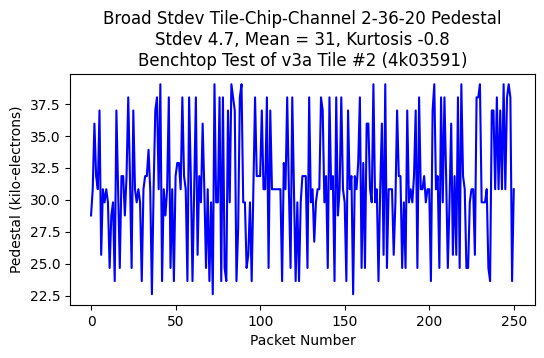

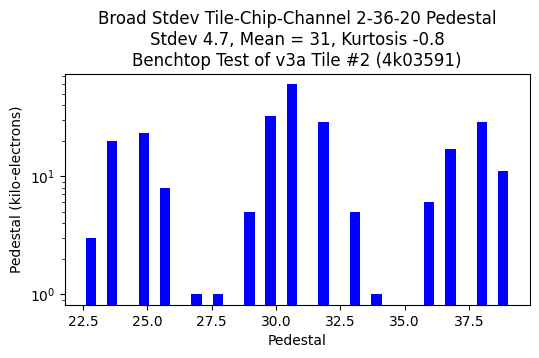

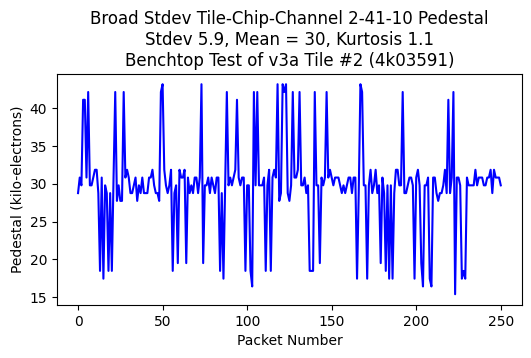

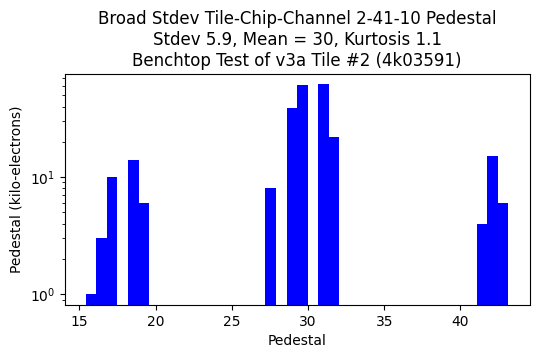

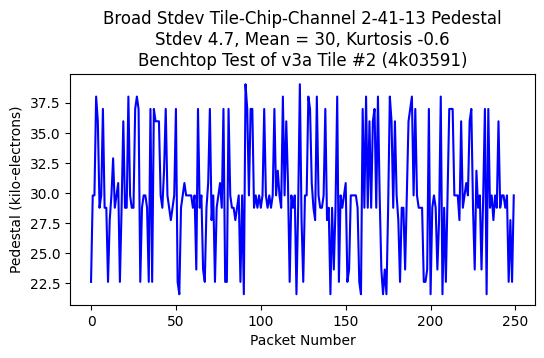

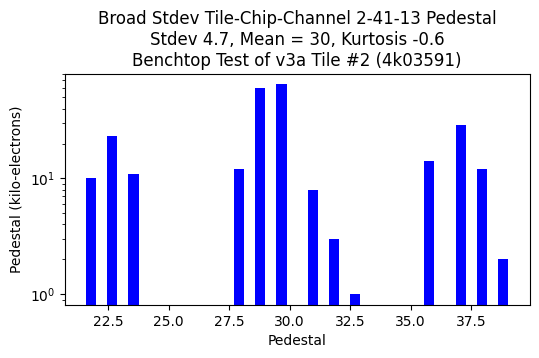

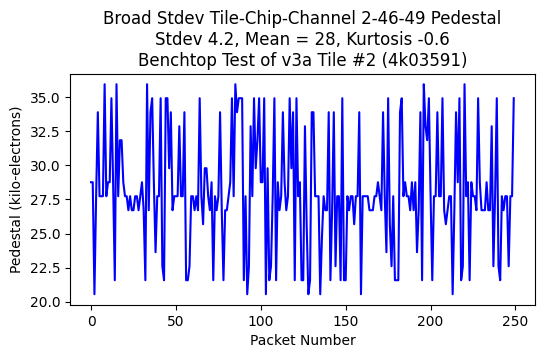

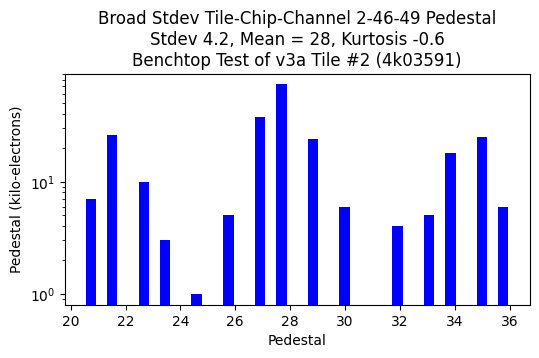

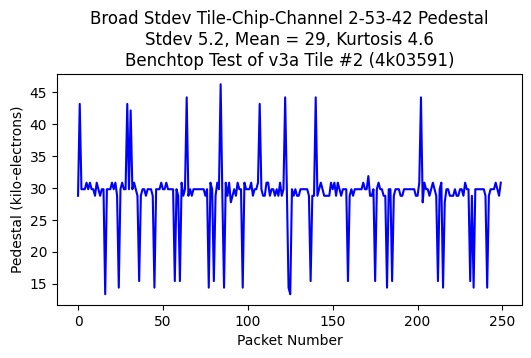

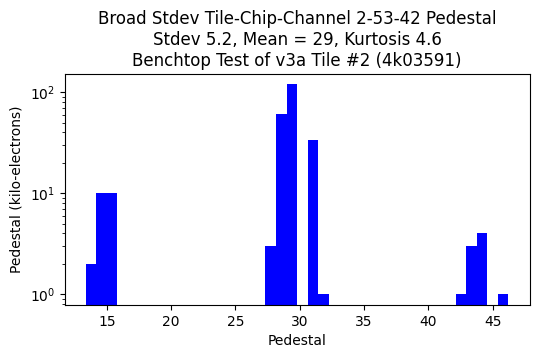

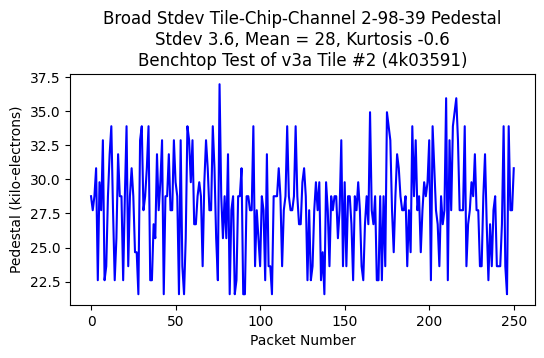

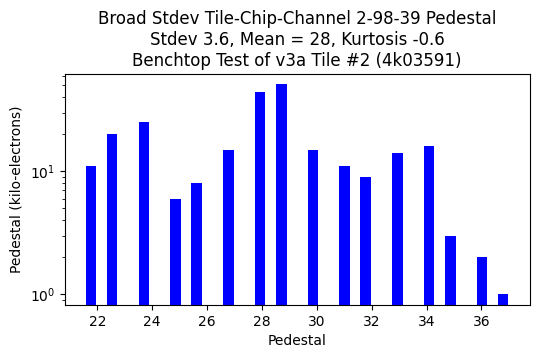

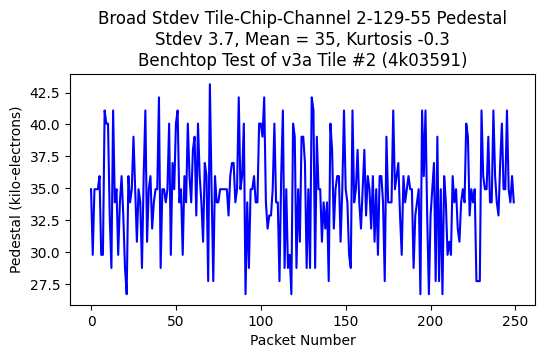

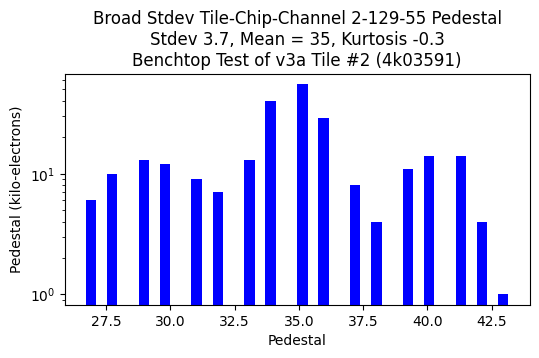

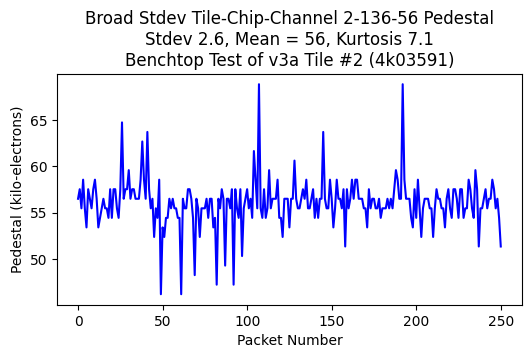

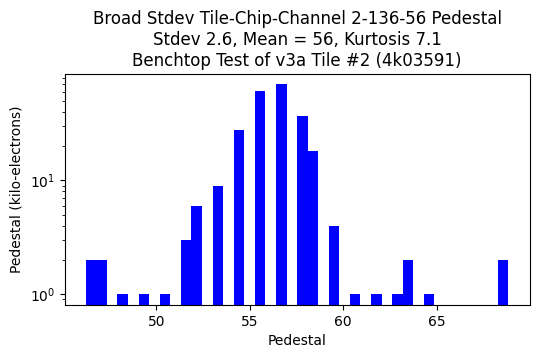

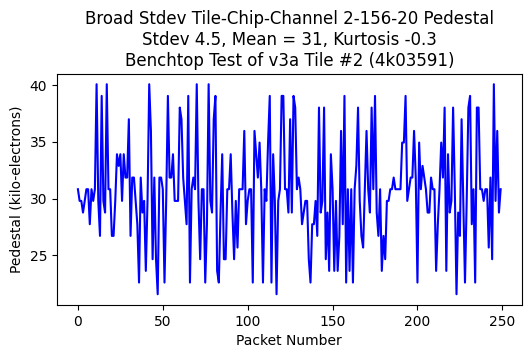

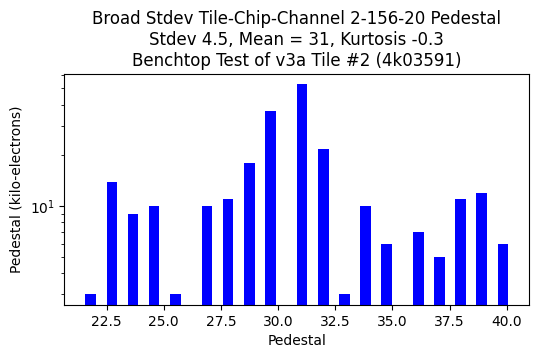

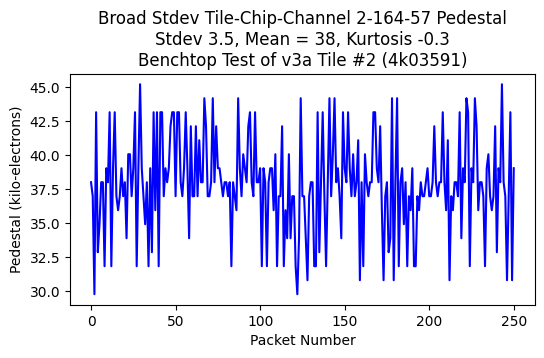

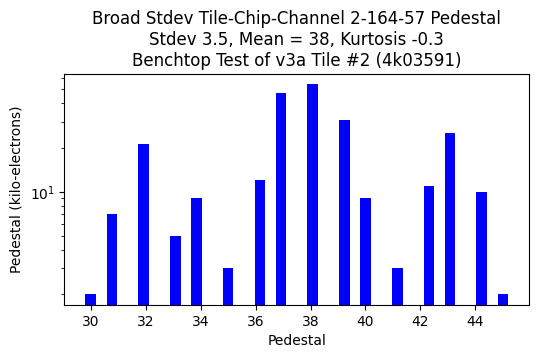

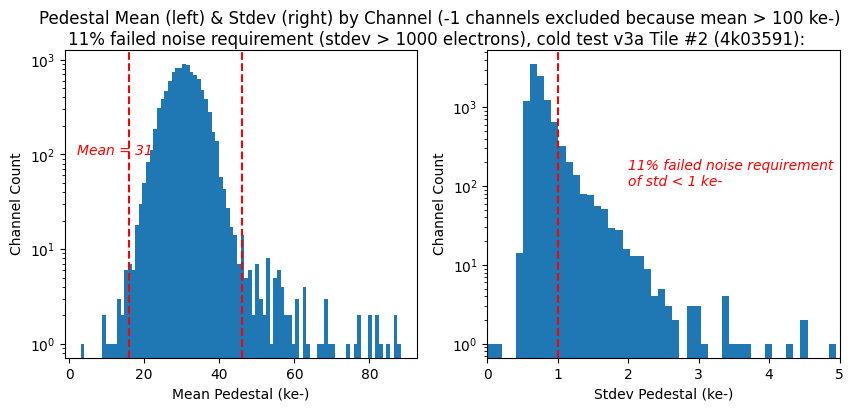

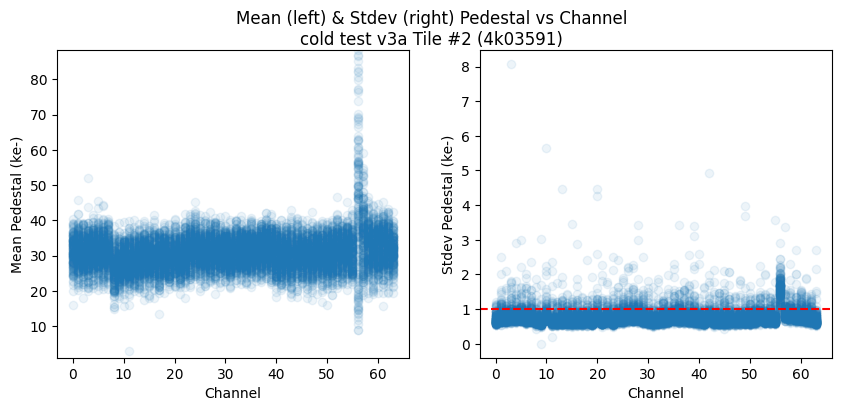

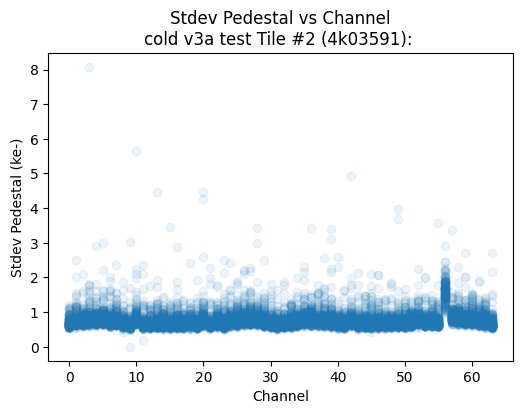

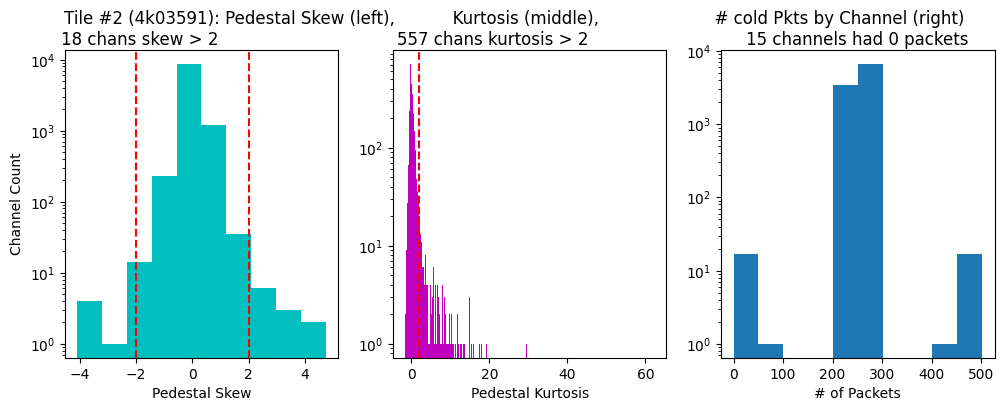

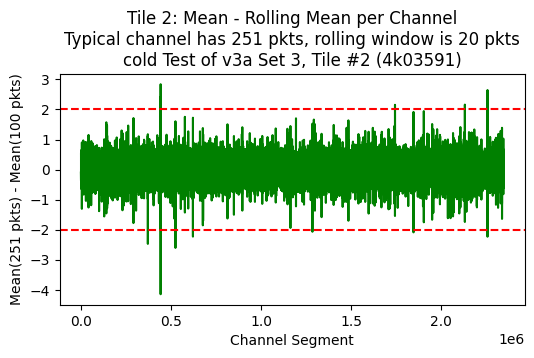

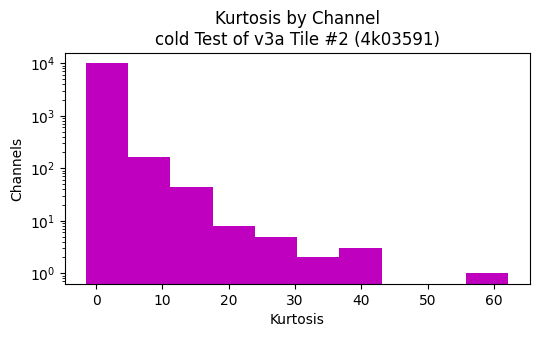

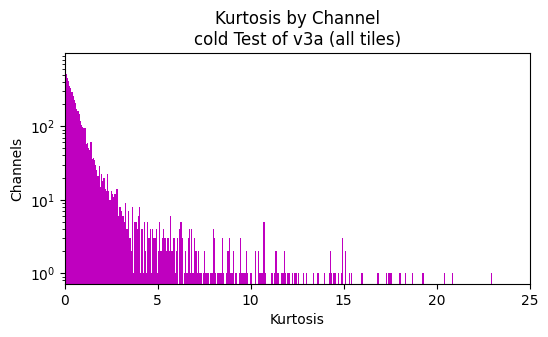

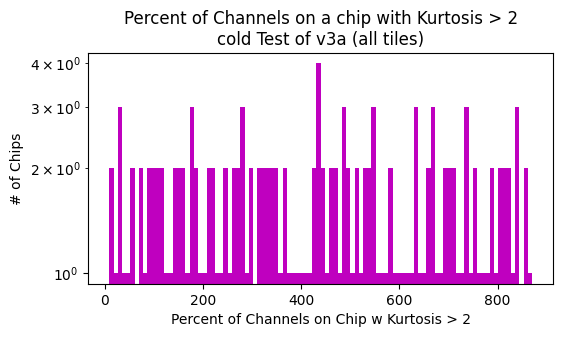

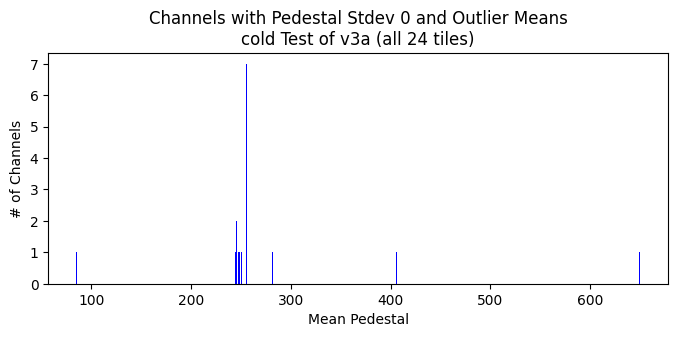

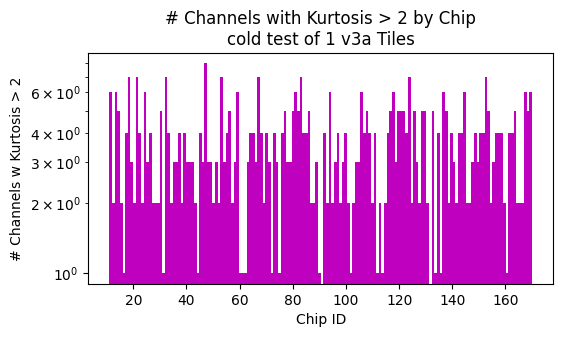

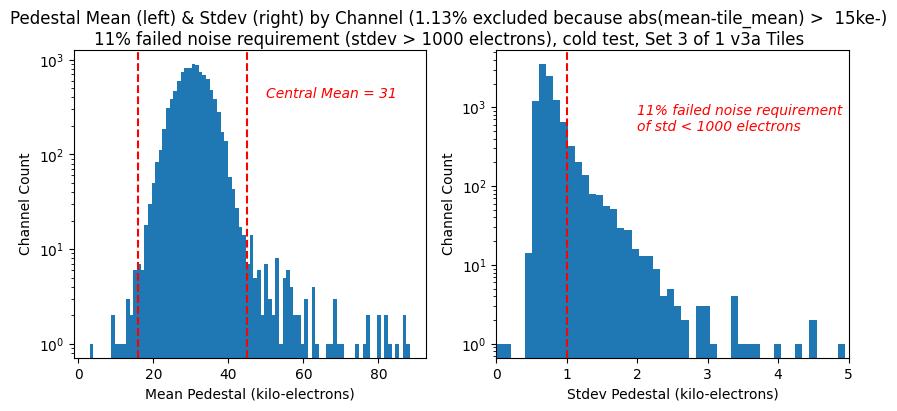

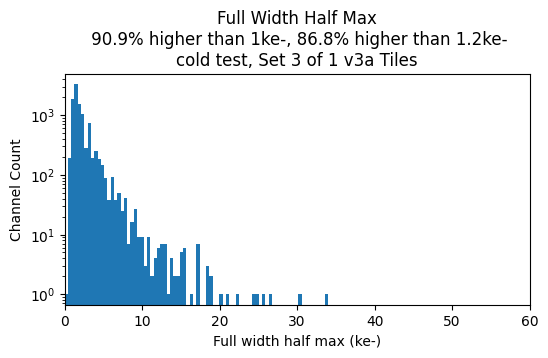

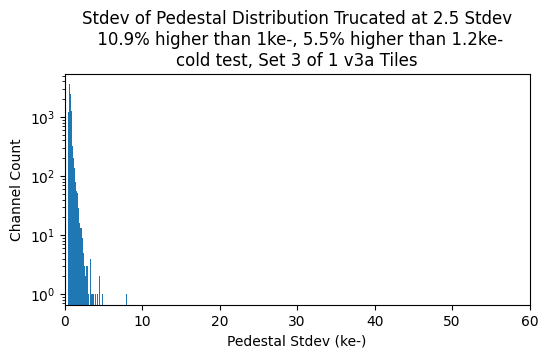

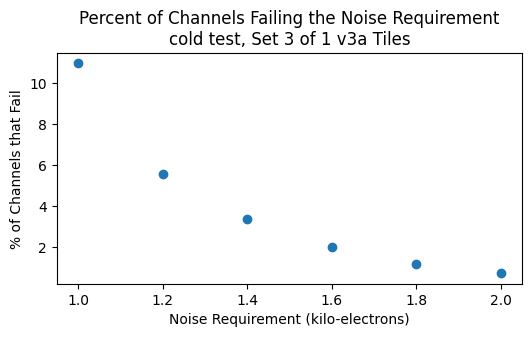

In [12]:
##### ####################
# main
####################

print(f'Raw data from File {filename}:')

# get the channel-specific results dictionary that holds results for all tiles from all tests 
import_results_dictionary()

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig)

graph_kurtosis()

graph_all_tiles(all_mean, all_std)

# store this set's results in dictionary for all 23 tile results
store_results()



Pedestal Noise Statistics for Set 3 of 1 tiles
	1.134% of channels were excluded because their mean was outside of range 1 electron to 2 x Tile Mean
	10.9% of channels had stdev > 1000 electrons
	5.5% of channels had stdev > 1200 electrons
	3.4% of channels had stdev > 1400 electrons
	2.0% of channels had stdev > 1600 electrons
	1.2% of channels had stdev > 1800 electrons
	0.7% of channels had stdev > 2000 electrons


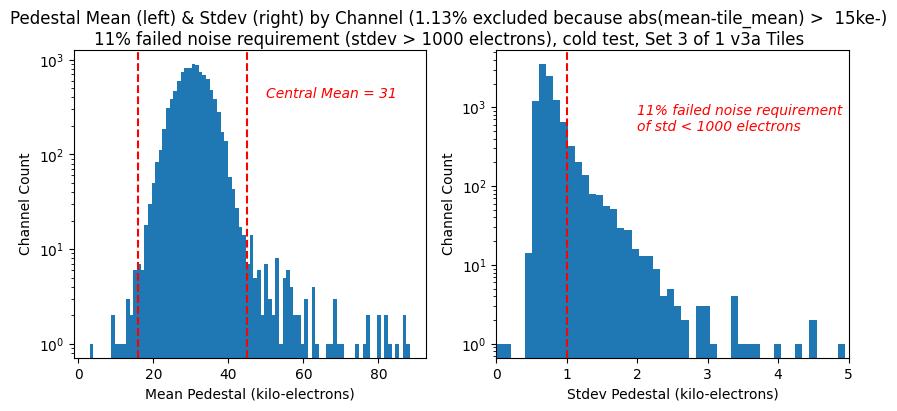

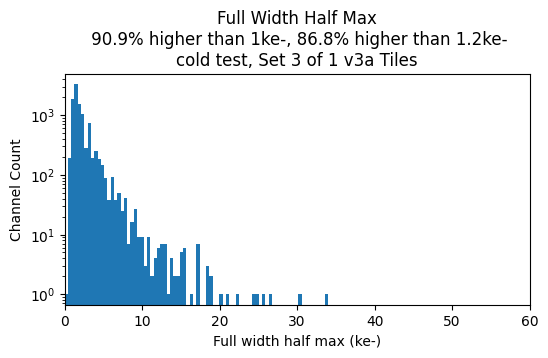

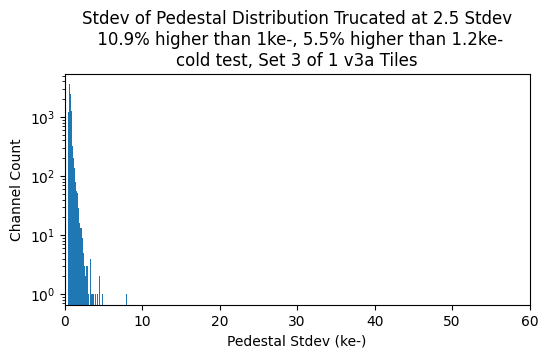

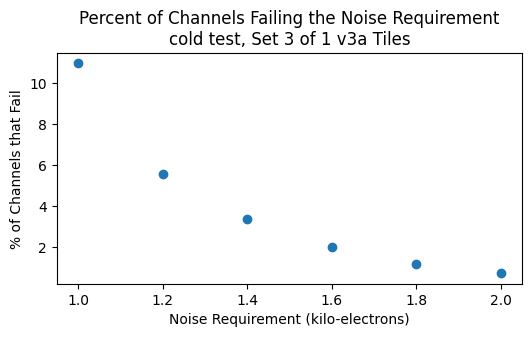

In [13]:
#graph_kurtosis()

graph_all_tiles(all_mean, all_std)